✅ 图像读取成功！
灰度图尺寸: (1824, 2736)
坐标[100,200]的灰度值: 42


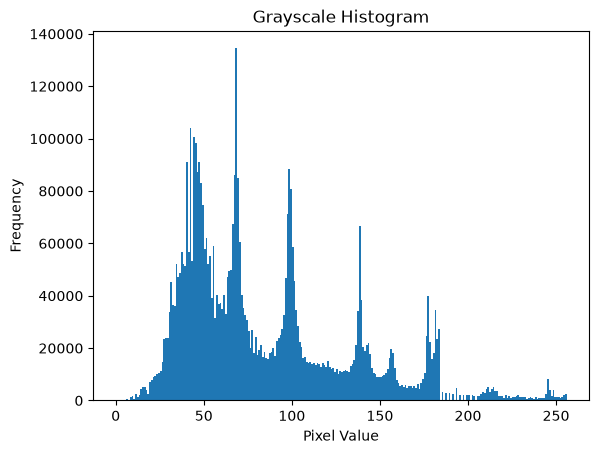

In [2]:
import matplotlib.pyplot as plt
import cv2
from image_utils import load_image_robust
img_path = r"D:\260526\2026-04-07\2026-04-07-16-16-01-394.tif"
img, ok= load_image_robust(img_path)
if ok:
       # 1. 转灰度
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    print(f"灰度图尺寸: {gray.shape}")  # 应该是 (高, 宽)，没有第三个维度了

    # 2. 看某个像素的灰度值
    print(f"坐标[100,200]的灰度值: {gray[100, 200]}")

    # 3. 画灰度直方图（这张图的亮度分布统计）
    plt.hist(gray.ravel(), bins=256, range=[0, 256])
    plt.title("Grayscale Histogram")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.show()
    # 方法1：手动设定阈值（先看直方图，尝试找一个值分离缺陷）

else:
        print("请检查路径后重试")


OTSU computed threshold: 107.0


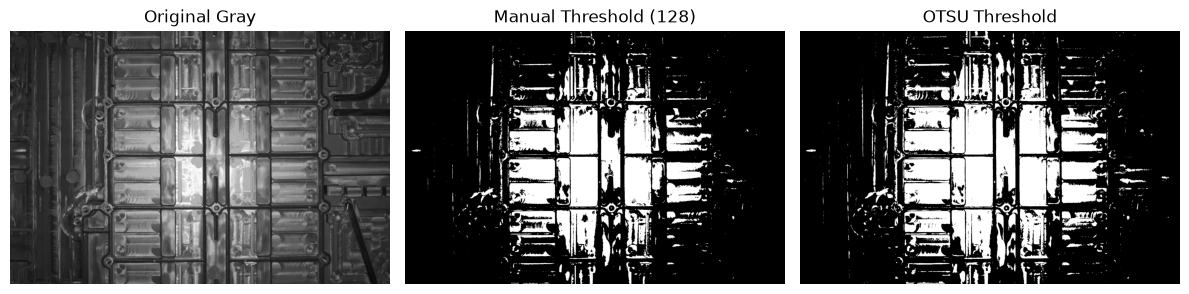

In [3]:
manual_thresh = 128  # 可根据直方图修改
_, binary_manual = cv2.threshold(gray, manual_thresh, 255, cv2.THRESH_BINARY)

# 方法2：OTSU 自动阈值（算法寻找最佳分割点，不必自己猜）
otsu_thresh, binary_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"OTSU computed threshold: {otsu_thresh}")

# 并排对比：原图灰度、手动二值、OTSU 二值
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title("Original Gray")
axes[1].imshow(binary_manual, cmap='gray')
axes[1].set_title(f"Manual Threshold ({manual_thresh})")
axes[2].imshow(binary_otsu, cmap='gray')
axes[2].set_title("OTSU Threshold")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

Threshold used: 107.0


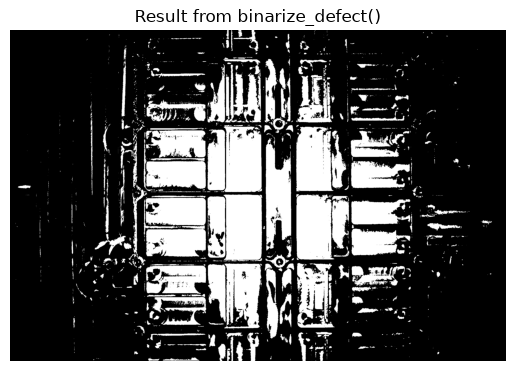

In [4]:
def binarize_defect(img_input, method='otsu', invert=False):
    """
    将图像二值化，分离缺陷区域。
    参数：
        img_input: 输入图像（可以是彩色或灰度）
        method: 二值化方法，'otsu' 表示自动阈值，'manual' 表示固定阈值128
        invert: 是否反阈值（缺陷为黑色时设为 True）
    返回：
        binary: 二值图像
        thresh_val: 使用的阈值
    """
    # 如果输入是彩色图，先转灰度
    if len(img_input.shape) == 3:
        gray_img = cv2.cvtColor(img_input, cv2.COLOR_BGR2GRAY)
    else:
        gray_img = img_input.copy()
    
    # 根据方法选择阈值处理方式
    if method == 'otsu':
        thresh_type = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY
        thresh_val, binary_img = cv2.threshold(gray_img, 0, 255, thresh_type + cv2.THRESH_OTSU)
    else:
        thresh_val = 128
        thresh_type = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY
        _, binary_img = cv2.threshold(gray_img, thresh_val, 255, thresh_type)
    
    return binary_img, thresh_val

# 测试封装后的函数
binary_test, used_thresh = binarize_defect(img, method='otsu', invert=False)
print(f"Threshold used: {used_thresh}")
plt.imshow(binary_test, cmap='gray')
plt.title("Result from binarize_defect()")
plt.axis('off')
plt.show()